In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, accuracy_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from scipy import stats
import matplotlib.cm as cm

In [87]:
df = pd.read_csv("cleaned_data.csv")


In [88]:
df


,patient_name,age,gender,condition,medication,visit_date,cholesterol,systolic,diastolic,visit_year,visit_month
0,david lee,25,other,Heart Disease,METFORMIN,2020-01-15,200.0,140.0,90.0,2020.0,1.0
1,emily davis,35,male,Diabetes,NONE,NaN,200.0,120.0,80.0,2020.0,1.0
2,laura martinez,35,other,Asthma,METFORMIN,NaN,160.0,110.0,70.0,2020.0,1.0
3,michael wilson,35,male,Diabetes,ALBUTEROL,2020-01-15,180.0,110.0,70.0,2020.0,1.0
4,david lee,35,female,Asthma,NONE,NaN,180.0,110.0,70.0,2020.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
995,mary clark,70,other,Asthma,ALBUTEROL,NaN,180.0,110.0,70.0,2020.0,1.0
996,mary clark,35,other,Asthma,LISINOPRIL,2020-01-15,160.0,130.0,85.0,2020.0,1.0
997,laura martinez,35,other,Asthma,ALBUTEROL,NaN,180.0,110.0,70.0,2020.0,1.0
998,jane smith,25,male,Asthma,ALBUTEROL,NaN,200.0,110.0,70.0,2020.0,1.0


K=2 → Silhouette: 0.3500
K=3 → Silhouette: 0.3724
K=4 → Silhouette: 0.3816
K=5 → Silhouette: 0.3904

✅ Best K selected: 5

📊 Cluster Summary (Mean Values):

               age  cholesterol    systolic  diastolic
cluster                                               
0        32.482014   184.604317  110.000000  70.000000
1        32.515528   173.788820  130.372671  85.186335
2        64.794521   187.397260  115.068493  75.068493
3        32.307692   209.711538  131.442308  85.721154
4        64.918919   186.486486  133.675676  86.837838


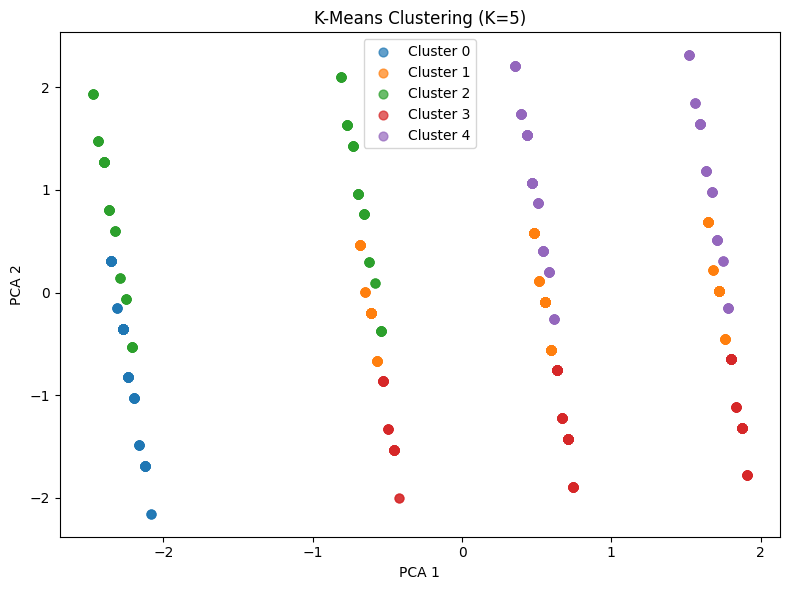


📊 Cluster Distribution:

cluster
0    139
1    322
2    146
3    208
4    185
Name: count, dtype: int64

📌 Percentage Distribution:

cluster
0    13.9
1    32.2
2    14.6
3    20.8
4    18.5
Name: proportion, dtype: float64


In [91]:
features = ['age', 'cholesterol', 'systolic', 'diastolic']
X = df[features].values

# ─────────────────────────────────────────────
# 2. SCALE DATA (IMPORTANT FOR K-MEANS)
# ─────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ─────────────────────────────────────────────
# 3. FIND BEST K USING SILHOUETTE SCORE
# ─────────────────────────────────────────────
sil_scores = []
K_range = range(2, 6)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

    print(f"K={k} → Silhouette: {score:.4f}")

best_k = K_range[np.argmax(sil_scores)]
print(f"\n✅ Best K selected: {best_k}")

# ─────────────────────────────────────────────
# 4. TRAIN FINAL K-MEANS MODEL
# ─────────────────────────────────────────────
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=50)
df['cluster'] = kmeans.fit_predict(X_scaled)

# ─────────────────────────────────────────────
# 5. CLUSTER STATISTICS (IMPORTANT STEP)
# ─────────────────────────────────────────────
print("\n📊 Cluster Summary (Mean Values):\n")
cluster_summary = df.groupby('cluster')[features].mean()
print(cluster_summary)

# ─────────────────────────────────────────────
# 6. PCA VISUALIZATION
# ─────────────────────────────────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

colors = cm.tab10(range(best_k))

plt.figure(figsize=(8, 6))

for i in range(best_k):
    mask = df['cluster'] == i
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=[colors[i]],
        label=f"Cluster {i}",
        s=40,
        alpha=0.7
    )

plt.title(f"K-Means Clustering (K={best_k})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 7. CLUSTER DISTRIBUTION
# ─────────────────────────────────────────────
print("\n📊 Cluster Distribution:\n")
print(df['cluster'].value_counts().sort_index())

print("\n📌 Percentage Distribution:\n")
print(df['cluster'].value_counts(normalize=True).sort_index() * 100)

In [92]:
# Rename clusters medically
cluster_names = {0: 'High BP Risk', 1: 'Normal BP'}
df_clean['Cluster_Label'] = df_clean['cluster'].map(cluster_names)

# Full summary
print("=" * 45)
print("CLUSTER ANALYSIS SUMMARY")
print("=" * 45)
print(f"\nTotal patients: {len(df_clean)}")
print(f"Silhouette Score: {km_sil:.4f}")
print(f"\nCluster sizes:")
print(df_clean['Cluster_Label'].value_counts())
print(f"\nMedical averages per cluster:")
print(df_clean.groupby('Cluster_Label')[['age','cholesterol',
                                          'systolic','diastolic']].mean().round(1))
print(f"\nTop conditions per cluster:")
print(df_clean.groupby('Cluster_Label')['condition'].value_counts())

CLUSTER ANALYSIS SUMMARY

Total patients: 1000
Silhouette Score: 0.4093

Cluster sizes:
Cluster_Label
Normal BP       592
High BP Risk    408
Name: count, dtype: int64

Medical averages per cluster:
                age  cholesterol  systolic  diastolic
Cluster_Label                                        
High BP Risk   44.1        186.1     114.8       74.8
Normal BP      42.5        187.8     133.9       87.0

Top conditions per cluster:
Cluster_Label  condition    
High BP Risk   Asthma           166
               Heart Disease     90
               Diabetes          83
               Hypertension      69
Normal BP      Asthma           251
               Diabetes         122
               Heart Disease    117
               Hypertension     102
Name: count, dtype: int64
